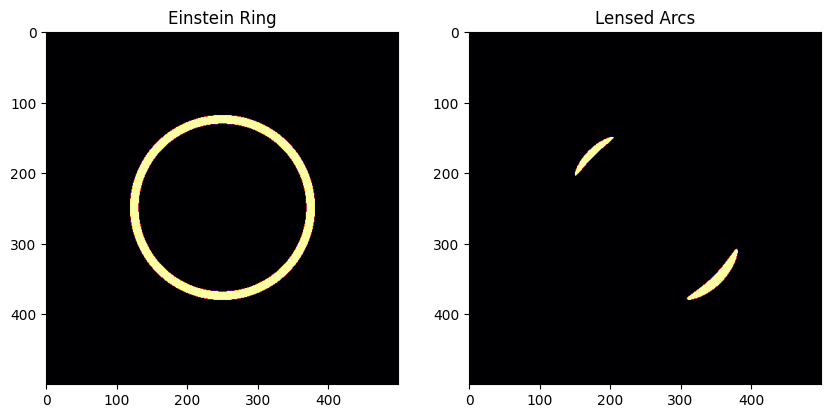

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_lensing(grid_size=500, lens_mass=1.0, source_pos=(0.05, 0.05)):
    """
    Simulates gravitational lensing by a point mass (Schwarzschild).
    All units are normalized for simplicity.
    """
    # 1. Create a coordinate grid (The Image Plane)
    x = np.linspace(-1, 1, grid_size)
    y = np.linspace(-1, 1, grid_size)
    xv, yv = np.meshgrid(x, y)
    
    # 2. Calculate distance from the center (Lens Position)
    r = np.sqrt(xv**2 + yv**2)
    r[r == 0] = 1e-9  # Prevent division by zero
    
    # 3. Define the Einstein Radius (theta_E)
    # In a real scenario, this depends on Mass and Distances.
    theta_E = 0.5 * np.sqrt(lens_mass)
    
    # 4. The Lens Equation: beta = theta - (theta_E^2 / theta)
    # We map every pixel (theta) back to its source position (beta)
    beta_x = xv - (theta_E**2 * xv / r**2)
    beta_y = yv - (theta_E**2 * yv / r**2)
    
    # 5. Define a circular background source
    source_radius = 0.05
    s_x, s_y = source_pos
    dist_from_source = np.sqrt((beta_x - s_x)**2 + (beta_y - s_y)**2)
    
    # 6. Apply "Brightness": If the ray hits the source, color it white
    image = np.where(dist_from_source < source_radius, 1.0, 0.0)
    
    return image

# Execution and Visualization
if __name__ == "__main__":
    # Case 1: Perfect alignment (Einstein Ring)
    ring_image = simulate_lensing(source_pos=(0, 0))
    
    # Case 2: Slight offset (Two Arcs)
    arc_image = simulate_lensing(source_pos=(0.1, 0.1))

    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.imshow(ring_image, cmap='inferno'), plt.title("Einstein Ring")
    plt.subplot(122), plt.imshow(arc_image, cmap='inferno'), plt.title("Lensed Arcs")
    plt.show()

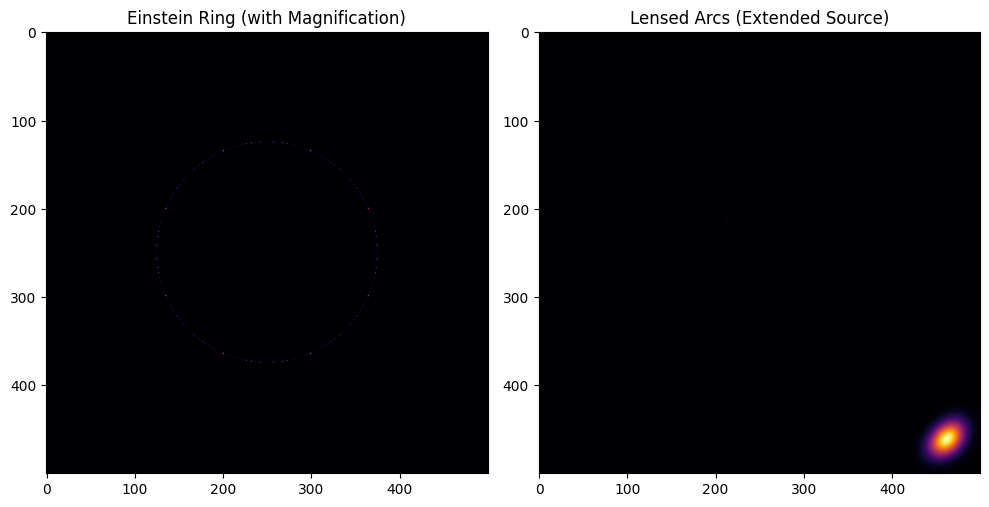

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_lensing(grid_size=500, lens_mass=1.0, source_pos=(0.01, 0.01)):
    """
    Research-level gravitational lensing simulation
    Includes magnification + extended source
    """

    # Grid (image plane)
    x = np.linspace(-1, 1, grid_size)
    y = np.linspace(-1, 1, grid_size)
    xv, yv = np.meshgrid(x, y)

    r = np.sqrt(xv**2 + yv**2)
    r[r == 0] = 1e-9

    # Einstein radius
    theta_E = 0.5 * np.sqrt(lens_mass)

    # Lens equation
    beta_x = xv - (theta_E**2 * xv / r**2)
    beta_y = yv - (theta_E**2 * yv / r**2)

    # -------- EXTENDED SOURCE (Gaussian) --------
    s_x, s_y = source_pos
    sigma = 0.05
    dist = np.sqrt((beta_x - s_x)**2 + (beta_y - s_y)**2)
    source = np.exp(-dist**2 / (2 * sigma**2))

    # -------- MAGNIFICATION --------
    # Jacobian matrix components
    d_beta_x_dx = 1 - theta_E**2 * (1/r**2 - 2*xv**2/r**4)
    d_beta_y_dy = 1 - theta_E**2 * (1/r**2 - 2*yv**2/r**4)
    d_beta_x_dy = 2 * theta_E**2 * xv * yv / r**4
    d_beta_y_dx = d_beta_x_dy

    # Determinant of Jacobian
    detA = d_beta_x_dx * d_beta_y_dy - d_beta_x_dy * d_beta_y_dx
    detA[detA == 0] = 1e-9

    magnification = 1 / np.abs(detA)

    # -------- FINAL IMAGE --------
    image = source * magnification

    return image


# Run simulation
if __name__ == "__main__":

    # Einstein Ring
    ring = simulate_lensing(source_pos=(0, 0))

    # Arcs
    arcs = simulate_lensing(source_pos=(0.7, 0.7))

    plt.figure(figsize=(10, 5))

    plt.subplot(121)
    plt.imshow(ring, cmap='inferno')
    plt.title("Einstein Ring (with Magnification)")

    plt.subplot(122)
    plt.imshow(arcs, cmap='inferno')
    plt.title("Lensed Arcs (Extended Source)")

    plt.tight_layout()
    plt.show()